# **Heart Disease Prediction**
### Machine Learning Project

> **Dataset:** UCI Heart Disease Dataset (303 patients, 14 features)  
> **Goal:** Predict whether a patient has heart disease (binary classification)

---

| Column | Description |
|--------|-------------|
| `age` | Age in years |
| `sex` | 1 = Male, 0 = Female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = True) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise induced angina (1 = Yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–4) |
| `thal` | Thalassemia (0 = Normal, 1 = Fixed defect, 2 = Reversable) |
| `target` | **1 = Heart Disease, 0 = No Heart Disease** |

# **IMPORTING REQUIRED LIBRARIES**

In [1]:
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;

# **LOADING THE DATASET**

In [2]:
df=pd.read_csv(r"C:\Users\ADITI DUNGYAN\Downloads\heart (2).csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# **UNDERSTANDING THE DATA**

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.shape

(303, 14)

In [6]:
df.size

4242

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# **CHECKING MISSING VALUES**

In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.isnull().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

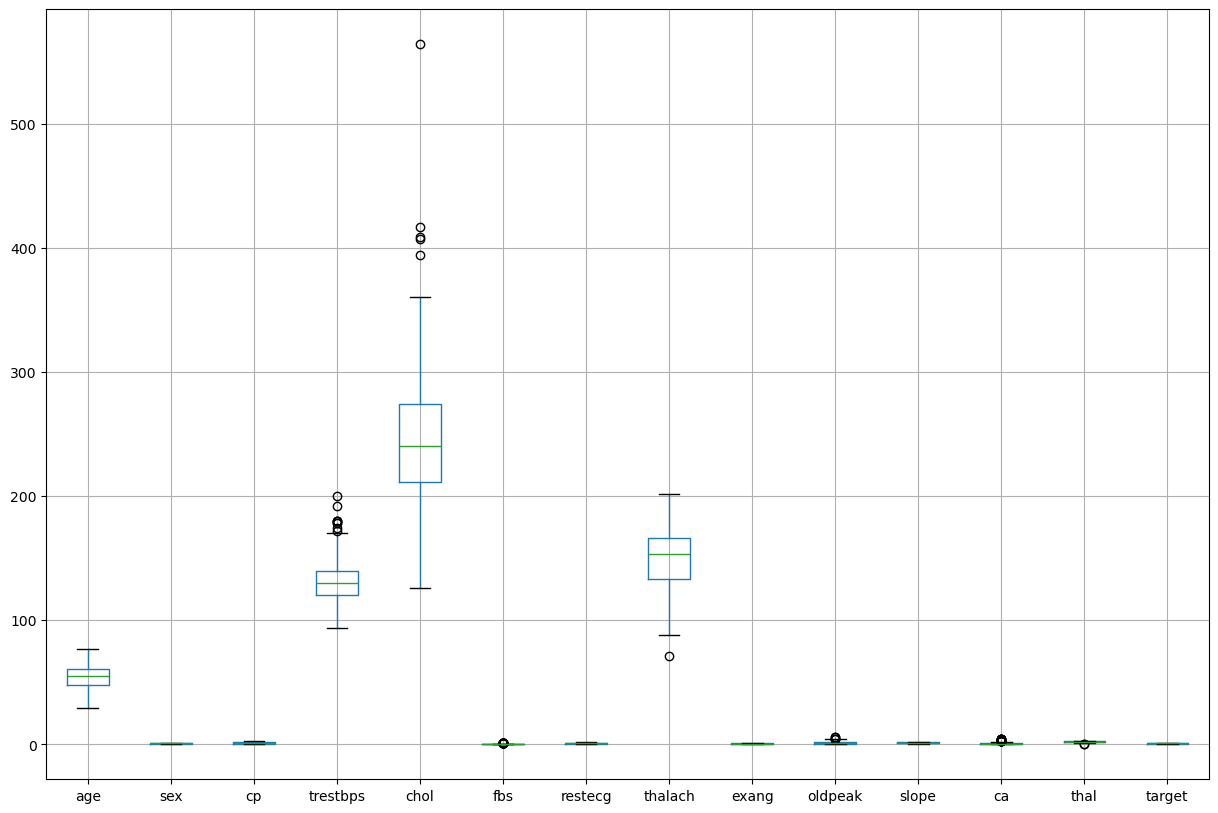

In [12]:
q=df.boxplot(figsize=(15,10))

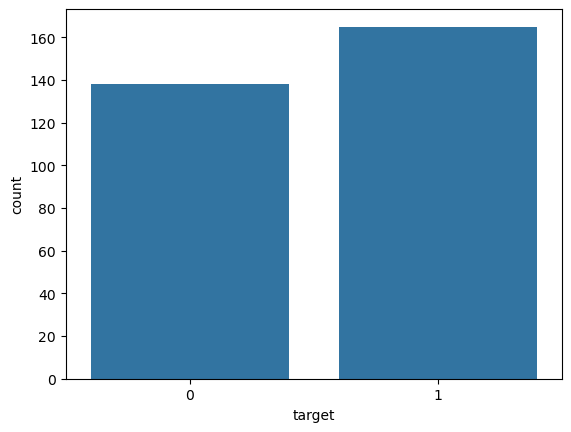

In [13]:
sns.countplot(x='target',data=df)
plt.show()

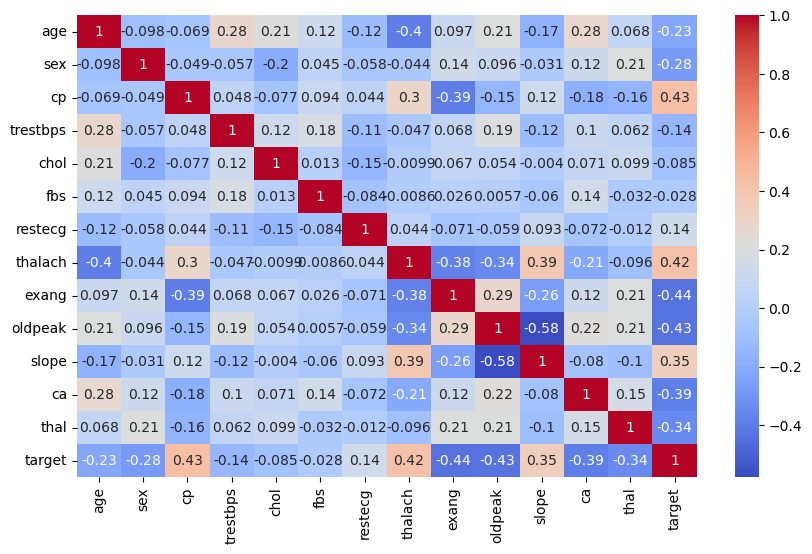

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

# **MODEL BUILDING**

In [15]:
from sklearn.model_selection import train_test_split

x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [17]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [18]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [19]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [20]:
y_train

132    1
202    0
196    0
75     1
176    0
      ..
188    0
71     1
106    1
270    0
102    1
Name: target, Length: 242, dtype: int64

In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.tree import DecisionTreeClassifier

In [24]:
# Initialize the Decision Tree Classifier
model_dt = DecisionTreeClassifier(random_state=42)

# Train the model
model_dt.fit(x_train, y_train)

# Make predictions
y_pred_dt = model_dt.predict(x_test)

# Calculate performance metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt)

# Print the performance metrics for Decision Tree
print('Decision Tree Metrics:')
print('Accuracy:', round(accuracy_dt, 2))
print('Precision:', round(precision_dt, 2))
print('Recall:', round(recall_dt, 2))
print('F1-Score:', round(f1_dt, 2))
print('Confusion Matrix:\n', conf_matrix_dt)
print('Classification Report:\n', class_report_dt)

Decision Tree Metrics:
Accuracy: 0.75
Precision: 0.84
Recall: 0.66
F1-Score: 0.74
Confusion Matrix:
 [[25  4]
 [11 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model_rf.fit(x_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(x_test)

# Calculate performance metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

# Print the performance metrics for Random Forest
print('Random Forest Metrics:')
print('Accuracy:', round(accuracy_rf, 2))
print('Precision:', round(precision_rf, 2))
print('Recall:', round(recall_rf, 2))
print('F1-Score:', round(f1_rf, 2))
print('Confusion Matrix:\n', conf_matrix_rf)
print('Classification Report:\n', class_report_rf)

Random Forest Metrics:
Accuracy: 0.84
Precision: 0.84
Recall: 0.84
F1-Score: 0.84
Confusion Matrix:
 [[24  5]
 [ 5 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [26]:
from sklearn.svm import SVC

# Initialize the SVM Classifier
model_svm = SVC(random_state=42)

# Train the model
model_svm.fit(x_train, y_train)

# Make predictions
y_pred_svm = model_svm.predict(x_test)

# Calculate performance metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)

# Print the performance metrics for SVM
print('SVM Metrics:')
print('Accuracy:', round(accuracy_svm, 2))
print('Precision:', round(precision_svm, 2))
print('Recall:', round(recall_svm, 2))
print('F1-Score:', round(f1_svm, 2))
print('Confusion Matrix:\n', conf_matrix_svm)
print('Classification Report:\n', class_report_svm)

SVM Metrics:
Accuracy: 0.7
Precision: 0.67
Recall: 0.88
F1-Score: 0.76
Confusion Matrix:
 [[15 14]
 [ 4 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.52      0.62        29
           1       0.67      0.88      0.76        32

    accuracy                           0.70        61
   macro avg       0.73      0.70      0.69        61
weighted avg       0.73      0.70      0.69        61



# **CROSS VALIDATION**

In [27]:
from sklearn.model_selection import ShuffleSplit, cross_val_score
import numpy as np

# Decision Tree Cross Validation
model_dt = DecisionTreeClassifier(random_state=42)
split = ShuffleSplit(n_splits=10, test_size=0.30, random_state=0)
results_dt = cross_val_score(model_dt, x, y, cv=split)

print('Decision Tree Cross-Validation Results:', results_dt)
print('Mean Accuracy:', round(np.mean(results_dt), 2))

# Random Forest Cross Validation
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
split = ShuffleSplit(n_splits=10, test_size=0.30, random_state=0)
results_rf = cross_val_score(model_rf, x, y, cv=split)

print('Random Forest Cross-Validation Results:', results_rf)
print('Mean Accuracy:', round(np.mean(results_rf), 2))

Decision Tree Cross-Validation Results: [0.73626374 0.73626374 0.68131868 0.72527473 0.73626374 0.72527473
 0.75824176 0.73626374 0.8021978  0.8021978 ]
Mean Accuracy: 0.74
Random Forest Cross-Validation Results: [0.84615385 0.8021978  0.75824176 0.81318681 0.82417582 0.85714286
 0.84615385 0.8021978  0.87912088 0.84615385]
Mean Accuracy: 0.83
